In [1]:
# ============================================================
# [0] 선형 회귀 실습용 가상 데이터 생성
# ============================================================
# 💡 데이터 공식: y = 4 + 3*X + 가우시안 노이즈
# - 진짜 파라미터: theta_0 = 4 (절편), theta_1 = 3 (기울기)
# - 목표: 학습 후 이 값들을 잘 복원하는지 확인!
# - np.random.seed(42): 재현성 보장
# - np.random.rand: 0~1 균등분포 → 2*...로 [0, 2] 범위
# - np.random.randn: 표준정규분포(평균 0, 표준편차 1) → 노이즈
# ============================================================

import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

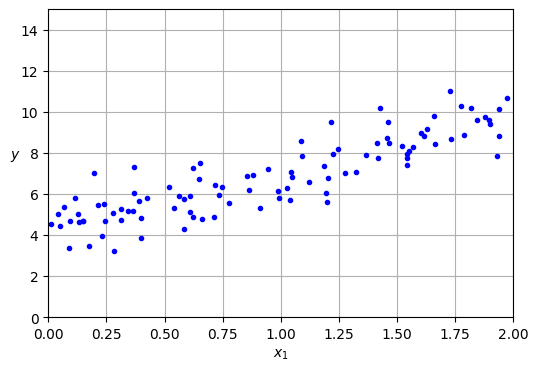

In [2]:
# [1] 생성된 데이터 시각화 - 직선 경향에 노이즈가 섞인 전형적인 선형 회귀 데이터

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [3]:
# ============================================================
# [2] 🔑 정규방정식(Normal Equation)으로 최적 파라미터 직접 계산
# ============================================================
# 💡 공식: θ_best = (X^T · X)^(-1) · X^T · y
#
# - add_dummy_feature(X): 편향항(1)을 X 앞에 추가 → X_b = [1, X]
#   (θ_0 를 가중치에 포함시켜 한 번에 계산하기 위함)
# - np.linalg.inv: 역행렬 계산
# - @ : 행렬 곱 연산자 (np.matmul과 동일)
#
# ⚠️ 장단점:
# ✅ 반복 없이 한 번에 최적해 (단 하나의 전역 최솟값)
# ❌ O(n^3) 역행렬 계산 → 특성 수(n)가 많으면 매우 느림
# ============================================================

from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.21509616],
       [2.77011339]])

In [4]:
# ============================================================
# [3] 학습된 θ로 새 데이터 예측
# ============================================================
# - X_new = [0, 2]: 예측할 두 점의 x값
# - X_new_b = [[1, 0], [1, 2]]: 편향 추가
# - y_predict = X_new_b @ θ = [θ_0 + θ_1*0, θ_0 + θ_1*2]
#   = [4, 10] (진짜 파라미터라면)
# ============================================================

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

<function matplotlib.pyplot.show(close=None, block=None)>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


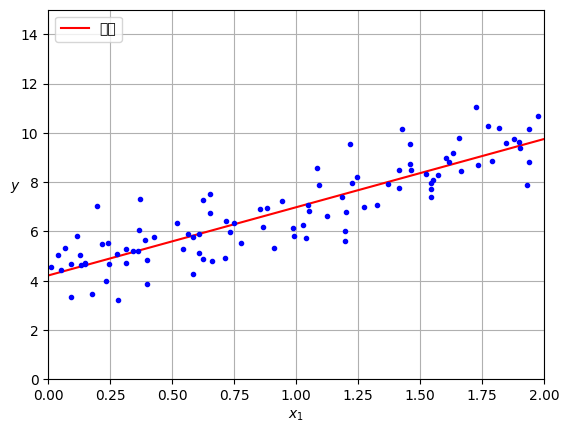

In [5]:
# [4] 학습된 직선과 원본 데이터 시각화
#     빨간 직선(예측)이 파란 점(실제)의 중심을 잘 지나감

import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="예측")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show

In [6]:
# ============================================================
# [5] 🔑 사이킷런 LinearRegression으로 동일한 작업
# ============================================================
# 💡 위의 수작업 정규방정식과 같은 결과
# - intercept_: 절편 (θ_0)
# - coef_: 가중치 (θ_1, θ_2, ...)
#
# 사이킷런은 내부적으로 더 안정적인 SVD 기반 방법 사용 (다음 셀)
# ============================================================

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [7]:
# [6] lin_reg.predict() → 수작업 결과와 같은 예측값

lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [8]:
# ============================================================
# [7] 💡 np.linalg.lstsq - SVD 기반 최소제곱법
# ============================================================
# 💡 정규방정식보다 수치적으로 안정적
# - 역행렬 계산이 불가능한 경우(특이 행렬)에도 작동
# - 사이킷런 LinearRegression이 내부적으로 사용하는 방식
# - rcond: 작은 특잇값(singular value) 임계치 (수치적 안정성)
# ============================================================

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [9]:
# ============================================================
# [8] 💡 유사역행렬(pseudoinverse)로 직접 계산
# ============================================================
# 💡 θ = X⁺ · y (X⁺는 X의 유사역행렬)
# - SVD로 계산되어 일반 역행렬보다 강건함
# - 특성이 샘플 수보다 많아도 작동
# ============================================================

np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

In [10]:
# ============================================================
# [9] 🔑 배치 경사 하강법 (Batch Gradient Descent)
# ============================================================
# 💡 핵심 공식:
# - 그래디언트: ∇θ MSE = (2/m) · X^T · (X·θ - y)
# - 업데이트: θ ← θ - η · ∇θ MSE
#
# 📌 "배치"인 이유: 매 스텝마다 전체 훈련 데이터(m개 전부) 사용
#
# - eta (η) = 0.1: 학습률 (너무 크면 발산, 너무 작으면 수렴 느림)
# - n_epochs = 1000: 반복 횟수
# - theta 초기값: 정규분포 난수
#
# ⚠️ 단점: m이 크면 매 스텝이 매우 느림 → SGD/미니배치 사용
# ============================================================

eta = 0.1
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
  gradients = 2 / m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

In [11]:
# ============================================================
# [10] 🔑 확률적 경사 하강법 (Stochastic Gradient Descent, SGD)
# ============================================================
# 💡 "확률적" = 매 스텝마다 샘플 하나만 무작위로 선택
#
# 📌 배치 GD와의 차이:
# - 한 스텝당 계산량: 배치 m개 → SGD 1개 (훨씬 빠름!)
# - 수렴 경로: 배치는 매끄럽게, SGD는 요동치며 수렴
#
# 💡 학습 스케줄(learning schedule):
# - learning_schedule(t): t가 커질수록 η가 작아짐
# - 초반: 큰 η로 빠르게 접근, 후반: 작은 η로 섬세하게 수렴
# - 지역 최솟값 탈출에도 도움
#
# n_epochs × m = 50 × 100 = 5000번 반복 (배치 1000번보다 많아 보이지만 각 반복이 훨씬 가벼움)
# ============================================================

n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
  return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
  for iteration in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index + 1]
    yi = y[random_index:random_index + 1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(epoch * m + iteration)
    theta = theta - eta * gradients

theta

array([[4.21076011],
       [2.74856079]])

In [12]:
# ============================================================
# [11] 🔑 사이킷런 SGDRegressor - SGD를 자동으로 처리
# ============================================================
# 💡 주요 하이퍼파라미터:
# - max_iter: 최대 에포크 수
# - tol: 수렴 판단 기준 (1e-5: 손실 변화가 이것보다 작으면 수렴)
# - penalty=None: 규제 없음 (Ridge/Lasso 쓸 땐 "l2", "l1")
# - eta0: 초기 학습률
# - n_iter_no_change=100: 개선 없는 에포크가 100번 연속이면 조기 종료
#
# ⚠️ y.ravel(): (m, 1) → (m,) 로 1차원 변환 (SGDRegressor 요구사항)
# ============================================================

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

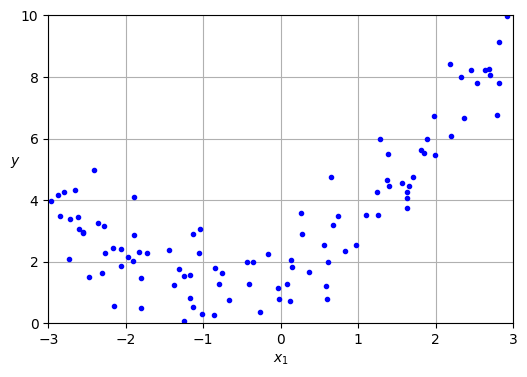

In [13]:
# ============================================================
# [12] 🔑 다항 회귀(Polynomial Regression)용 비선형 데이터 생성
# ============================================================
# 💡 데이터 공식: y = 0.5·X² + X + 2 + 노이즈
# - 2차 함수 형태 (곡선)
# - 단순 선형 회귀로는 과소적합 발생
# - 다항 회귀로 해결!
# ============================================================

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

In [14]:
# ============================================================
# [13] 🔑 PolynomialFeatures - 다항 특성 생성
# ============================================================
# 💡 원본 특성을 거듭제곱한 새 특성을 추가
# - degree=2: X, X² 특성 생성 (X^0=1은 include_bias=False로 제외)
# - X[0] = 원본 첫 샘플 확인 (숫자 하나만 있음)
# ============================================================

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [15]:
# [14] X_poly[0] = [X, X²] 형태의 새 특성
#      예: X=0.75 → [0.75, 0.5625]

X_poly[0]

array([-0.75275929,  0.56664654])

In [16]:
# ============================================================
# [15] 💡 재밌는 포인트: "다항 회귀" 실제론 "특성 확장 + 선형 회귀"
# ============================================================
# - 확장된 특성 [X, X²]에 그냥 LinearRegression 적용
# - 학습된 계수: 대략 X 계수≈1, X² 계수≈0.5, 절편≈2
# - 원본 공식 0.5·X² + X + 2와 거의 일치!
# ============================================================

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

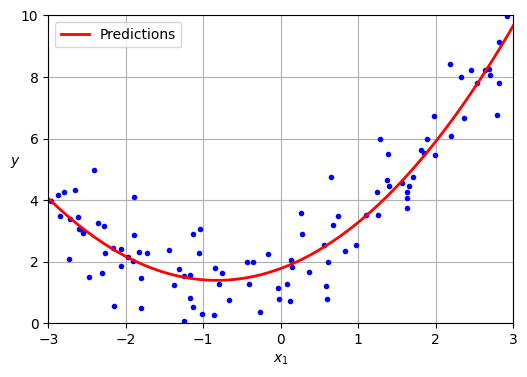

In [17]:
# [16] 💡 학습된 2차 곡선 시각화
#      - X_new로 부드러운 x축 값 100개 생성
#      - 데이터 점들 사이를 곡선이 멋지게 통과

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2,
         label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

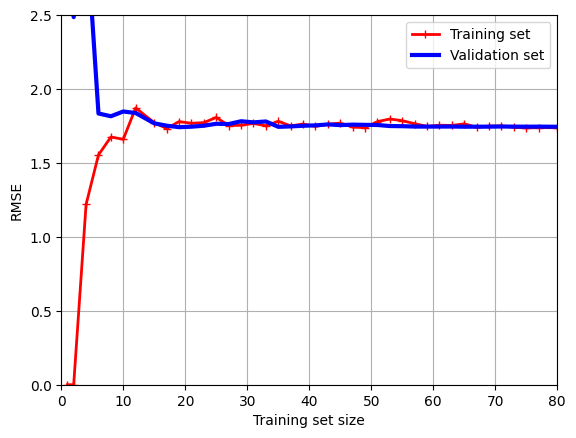

In [18]:
# ============================================================
# [17] 🔑 학습 곡선 (Learning Curves) - 과소/과대적합 진단 도구
# ============================================================
# 💡 훈련 세트 크기에 따른 훈련/검증 RMSE 변화 시각화
#
# - train_sizes=np.linspace(0.01, 1.0, 40): 훈련 크기를 1%~100% 40단계
# - cv=5: 5-폴드 교차 검증
# - scoring="neg_root_mean_squared_error": RMSE의 음수 (부호 뒤집어 사용)
#
# 📌 선형 회귀를 2차 데이터에 적용 → 과소적합 패턴:
# - 두 곡선이 높은 값에서 가까이 수렴 (둘 다 못함)
# - 데이터를 더 줘도 성능이 거의 개선 안 됨
# ============================================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Training set")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="Validation set")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

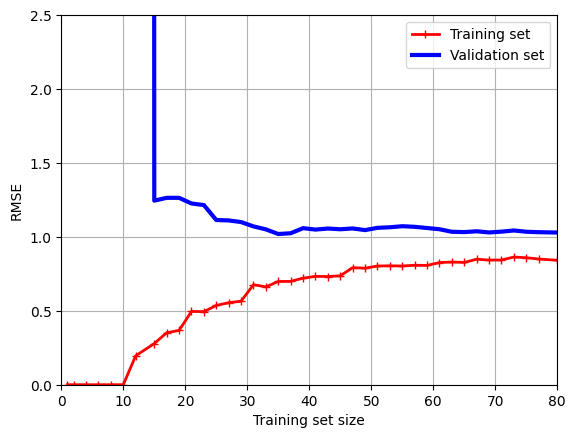

In [19]:
# ============================================================
# [18] 🔑 10차 다항 회귀의 학습 곡선 - 과대적합 패턴
# ============================================================
# 💡 make_pipeline으로 전처리+모델 묶기
# - PolynomialFeatures(degree=10): 과도하게 복잡한 모델
#
# 📌 과대적합 패턴:
# - 훈련 오차 << 검증 오차 (두 곡선 사이 "간격(gap)"이 큼)
# - 훈련 세트는 잘 맞추지만 검증 세트는 잘 못함
#
# 💡 과소적합 vs 과대적합 학습곡선 요약:
# - 과소적합: 두 곡선이 높은 값에서 가까움 → 모델 더 복잡하게
# - 과대적합: 두 곡선 사이 간격이 큼 → 더 많은 데이터 or 규제
# ============================================================

from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Training set")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="Validation set")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

In [20]:
# [19] 🔑 규제 모델 실습용 소량 데이터 (20개)
#      y = 1 + 0.5·X + 작은 노이즈 (단순 선형 관계)

np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

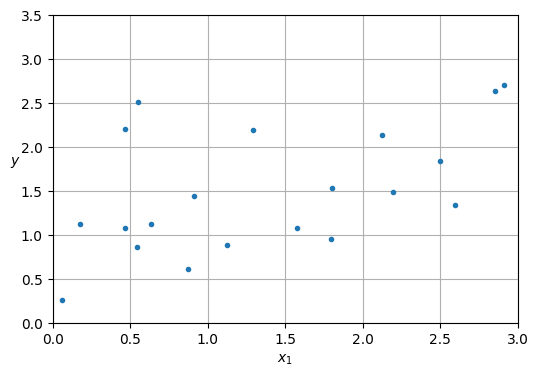

In [21]:
# [20] 데이터 시각화

plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$ ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [22]:
# ============================================================
# [21] 🔑 릿지 회귀 (Ridge Regression) - L2 규제
# ============================================================
# 💡 비용 함수: MSE + α · Σ(θᵢ²) / 2
#
# 📌 특징:
# - 가중치를 0에 "가깝게" 만들지만 0으로는 안 만듦
# - alpha: 규제 강도 (클수록 규제 강함)
# - solver="cholesky": 클로스키 분해로 풀이 (빠르고 안정)
#
# 언제 쓰나?
# - 특성이 모두 어느 정도 예측에 기여할 때
# - 과대적합을 줄이고 싶을 때 (기본 선택지)
# ============================================================

from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

In [23]:
# ============================================================
# [22] 💡 SGDRegressor로 릿지 회귀 구현
# ============================================================
# - penalty="l2": L2 규제 → 릿지 회귀와 동등
# - alpha=0.1/m: SGD는 규제가 다르게 적용되어 m으로 나눔
# - tol=None: 조기 종료 없이 max_iter만큼 학습
#
# ⚠️ 앞선 Ridge와 비슷한 결과를 얻어야 정상
# ============================================================

sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

In [24]:
# ============================================================
# [23] 🔑 라쏘 회귀 (Lasso Regression) - L1 규제
# ============================================================
# 💡 비용 함수: MSE + α · Σ|θᵢ|
#
# 📌 특징 (릿지와의 차이):
# - 덜 중요한 특성의 가중치를 완전히 0으로 만듦 ⭐
# - 자동 특성 선택(feature selection) 효과
# - 희소(sparse) 모델 생성
#
# 언제 쓰나?
# - 일부 특성만 실제로 중요하고 나머지는 불필요하다고 예상될 때
# ============================================================

from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

In [25]:
# ============================================================
# [24] 🔑 엘라스틱넷 (ElasticNet) - L1 + L2 혼합
# ============================================================
# 💡 비용 함수: MSE + r · α · Σ|θᵢ| + (1-r)/2 · α · Σ(θᵢ²)
#
# - l1_ratio=0.5: L1과 L2를 반반씩 섞음
#   - l1_ratio=0 → 릿지와 동일
#   - l1_ratio=1 → 라쏘와 동일
#
# 💡 언제 쓰나?
# - 특성 수가 샘플 수보다 많거나 특성 간 강한 상관관계가 있을 때
# - 라쏘의 특성 선택 + 릿지의 안정성을 모두 원할 때
# ============================================================

from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

In [26]:
# ============================================================
# [25] 🔑 조기 종료(Early Stopping) 구현 - 과대적합 방지
# ============================================================
# 💡 핵심 아이디어: 검증 오차가 최소인 순간의 모델을 저장
#
# 📌 의도적으로 과대적합을 유도:
# - degree=90: 극단적으로 복잡한 모델
# - StandardScaler: 높은 차수로 인한 수치 불안정 완화
#
# 📌 학습 루프:
# - partial_fit(): 한 에포크씩 점진적 학습 (fit과 달리 상태 유지)
# - 매 에포크마다 검증 오차 측정
# - if val_error < best_valid_rmse: 기록 갱신 + deepcopy로 모델 저장
#
# 💡 왜 deepcopy?
# - best_model = sgd_reg 로 하면 참조라서 다음 에포크에 같이 바뀜
# - deepcopy로 독립된 복사본 생성 → 진짜 "그때의 모델" 보존
# ============================================================

from copy import deepcopy
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []
for epoch in range(n_epochs):
  sgd_reg.partial_fit(X_train_prep, y_train)
  y_valid_predict=sgd_reg.predict(X_valid_prep)
  val_error = mean_squared_error(y_valid, y_valid_predict)
  val_error = np.sqrt(val_error)
  if val_error < best_valid_rmse:
    best_valid_rmse = val_error
    best_model = deepcopy(sgd_reg)

  y_train_predict = sgd_reg.predict(X_train_prep)
  train_error = mean_squared_error(y_train, y_train_predict)
  train_error = np.sqrt(train_error)

  val_errors.append(val_error)
  train_errors.append(train_error)

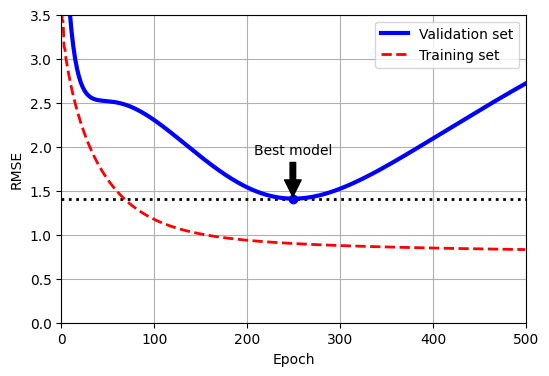

In [27]:
# ============================================================
# [26] 💡 조기 종료 지점 시각화
# ============================================================
# 👁️ 관찰 포인트:
# - 훈련 오차(빨강): 계속 감소 (과대적합 중)
# - 검증 오차(파랑): 감소하다가 어느 지점부터 증가 ⭐
# - best_epoch: 검증 오차가 최저인 시점 = 최적 모델
#
# → 이 지점에서 학습을 멈추는 게 가장 일반화 성능 좋음!
# ============================================================

best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()

plt.show()

In [28]:
# ============================================================
# [27] 🔑 붓꽃(Iris) 데이터셋 로드 - 로지스틱 회귀 실습
# ============================================================
# 💡 유명한 분류 예제 데이터셋
# - 3개 종류(setosa, versicolor, virginica)의 붓꽃
# - 4개 특성: 꽃받침/꽃잎의 길이와 너비
# - 150개 샘플 (종당 50개)
# - as_frame=True: pandas DataFrame 형태로 받기
# ============================================================

from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [29]:
# [28] 특성 데이터 확인 - 4개 수치 특성

iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [30]:
# [29] 타깃 확인 - 0, 1, 2 (세 종류)

iris.target.head(3)

,target
0,0
1,0
2,0


In [31]:
# [30] 클래스 이름 확인 → ['setosa', 'versicolor', 'virginica']

iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [32]:
# ============================================================
# [31] 🔑 로지스틱 회귀 (Logistic Regression) - 이진 분류
# ============================================================
# 💡 "이 붓꽃은 virginica인가?" 이진 분류 문제로 단순화
#
# 📌 로지스틱 회귀란?
# - 선형 회귀 결과를 시그모이드(sigmoid) 함수에 넣어 확률로 변환
# - σ(z) = 1 / (1 + e^(-z)) → 0~1 사이 확률값
# - 확률 0.5 이상이면 양성 분류
#
# 📌 설정:
# - petal width 1개 특성만 사용 (단순화)
# - y: virginica이면 True, 아니면 False
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


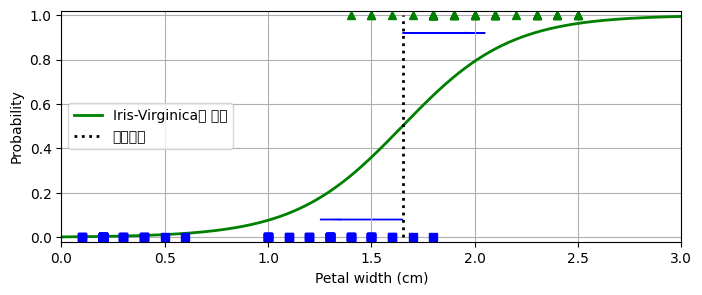

In [33]:
# ============================================================
# [32] 💡 결정 경계(decision boundary) 시각화
# ============================================================
# - predict_proba: 각 클래스 확률 반환
# - y_proba[:, 1]: 양성(virginica) 확률
# - decision_boundary: 확률이 처음으로 0.5를 넘는 x값
#
# 👁️ 관찰:
# - 약 1.6cm 지점에서 결정 경계 형성
# - 꽃잎 너비가 이보다 크면 virginica로 분류
# - S자 모양 시그모이드 곡선이 특징
# ============================================================

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
plt.figure(figsize=(8, 3))
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris-Virginica일 확률")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="결정경계")
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0, head_length=0.1, fc="b", ec="b")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.show()

In [34]:
# [33] 결정 경계 값 확인 (약 1.66cm)

decision_boundary

np.float64(1.6516516516516517)

In [35]:
# [34] 💡 실제 예측 확인
#      - [[1.7]] → True (1.7 > 1.66 이므로 virginica)
#      - [[1.5]] → False (1.5 < 1.66)

log_reg.predict([[1.7], [1.5]])

array([ True, False])

In [36]:
# ============================================================
# [35] 🔑 소프트맥스 회귀 (Softmax Regression) - 다중 클래스 분류
# ============================================================
# 💡 로지스틱 회귀의 다중 클래스 버전
# - 각 클래스마다 점수(logit) 계산 → 소프트맥스로 확률 변환
# - softmax(z_i) = e^(z_i) / Σ e^(z_j)
# - 가장 높은 확률의 클래스로 분류
#
# 📌 설정:
# - 특성 2개 사용: petal length, petal width
# - 타깃 3개 클래스 전체 사용
# - C=30: 규제 역수 (클수록 규제 약함, 사이킷런 LR은 기본 L2 규제)
#
# 💡 사이킷런 LogisticRegression은 다중 클래스에서 자동으로 소프트맥스 사용
# ============================================================

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [37]:
# [36] 예측: petal length=5, width=2 → 어느 클래스?
#      결과는 가장 확률 높은 한 클래스 (보통 2: virginica)

softmax_reg.predict([[5, 2]])

array([2])

In [38]:
# [37] 💡 각 클래스별 확률 확인
#      예: [0.00, 0.04, 0.96] → virginica 96% 확률로 예측

softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

In [39]:
# ============================================================
# [38] 🎓 연습문제: 소프트맥스 회귀 직접 구현 시작
# ============================================================
# 💡 사이킷런 없이 NumPy로 밑바닥부터 구현 → 내부 원리 이해!
#
# - X_with_bias: np.c_[ones, X] → 맨 앞 열에 편향항 1 추가
#   θ_0를 가중치에 포함시켜 행렬 연산만으로 처리 가능
# ============================================================

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values
X_with_bias = np.c_[np.ones(len(X)), X]

In [40]:
# ============================================================
# [39] 🔑 train/valid/test 직접 분할 (60/20/20)
# ============================================================
# 💡 np.random.permutation(N): 0~N-1을 무작위로 섞은 배열
# - 이 인덱스로 데이터를 섞어서 분할
# - train_test_split 없이 수동으로 구현해보는 연습
#
# 📌 분할 방식:
# - 앞 train_size개 → 훈련
# - 중간 validation_size개 → 검증
# - 마지막 test_size개 → 테스트
# ============================================================

test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]
X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]
X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

In [41]:
# ============================================================
# [40] 💡 원-핫 인코딩(one-hot encoding) 함수 직접 구현
# ============================================================
# 💡 아이디어: np.diag(np.ones(K))로 K×K 단위 행렬을 만든 뒤,
#           y의 각 값을 인덱스로 사용해 해당 행 선택
#
# 예: y=[0,1,2,1] →
# [[1,0,0], [0,1,0], [0,0,1], [0,1,0]]
#
# 소프트맥스의 타깃은 원-핫 형태여야 크로스 엔트로피 계산 가능
# ============================================================

def to_one_hot(y):
  return np.diag(np.ones(y.max() + 1))[y]

In [42]:
# [41] 원본 y_train 처음 10개 (0, 1, 2 정수)

y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [43]:
# [42] 원-핫 인코딩된 결과 - 각 행에 하나의 1만 있음

to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [44]:
# [43] 훈련/검증/테스트 레이블 모두 원-핫 변환

Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

In [45]:
# ============================================================
# [44] 💡 특성 스케일링 (직접 구현)
# ============================================================
# 💡 StandardScaler와 동일한 작업을 수동으로:
# - 훈련 세트의 평균/표준편차 계산
# - (X - mean) / std 로 표준화
#
# ⚠️ [:, 1:] 주의: 편향항(첫 번째 열의 1)은 스케일링에서 제외!
# ⚠️ 검증/테스트에는 훈련 세트에서 구한 평균/표준편차 사용 (데이터 누수 방지)
# ============================================================

mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

In [46]:
# ============================================================
# [45] 🔑 소프트맥스 함수 구현
# ============================================================
# 💡 공식: softmax(z_i) = e^(z_i) / Σ_j e^(z_j)
#
# - logits: 각 샘플의 각 클래스 점수 (m × K 행렬)
# - exps.sum(axis=1): 각 행별 합산 (K개 클래스 확률의 합 = 1)
# - keepdims=True: 브로드캐스팅을 위해 차원 유지
#
# 결과: 각 행이 확률분포(합=1, 모두 양수)
# ============================================================

def softmax(logits):
  exps = np.exp(logits)
  exp_sums = exps.sum(axis=1, keepdims=True)
  return exps / exp_sums

In [47]:
# [46] 입력 특성 개수(편향 포함)와 출력 클래스 개수 설정
#      θ 행렬 크기는 (n_inputs, n_outputs)

n_inputs = X_train.shape[1]
n_outputs = len(np.unique(y_train))

In [48]:
# ============================================================
# [47] 🔑 소프트맥스 회귀 수동 학습 (경사 하강법)
# ============================================================
# 💡 학습 단계:
# 1. logits = X @ Θ (선형 조합)
# 2. Y_proba = softmax(logits) (확률 변환)
# 3. error = Y_proba - Y_one_hot (예측 - 실제)
# 4. gradients = (1/m) · X^T · error
# 5. Θ ← Θ - η · gradients
#
# 💡 크로스 엔트로피 손실:
# -Σ y_true · log(y_pred + ε)
# - epsilon 더하기: log(0) = -∞ 방지
#
# 📌 1000 에포크마다 검증 손실 출력 → 잘 감소하는지 확인
# ============================================================

eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
  logits = X_train @ Theta
  Y_proba = softmax(logits)
  if epoch % 1000 == 0:
    Y_proba_valid = softmax(X_valid @ Theta)
    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    print(epoch, xentropy_losses.sum(axis=1).mean())
  error = Y_proba - Y_train_one_hot
  gradients = 1 / m * X_train.T @ error
  Theta = Theta - eta * gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


In [49]:
# [48] 학습된 Θ 확인 - (3, 3) 행렬 (편향+2특성) × 3클래스

Theta

array([[ 0.41931626,  6.11112089, -5.52429876],
       [-6.53054533, -0.74608616,  8.33137102],
       [-5.28115784,  0.25152675,  6.90680425]])

In [50]:
# [49] 💡 검증 세트 정확도 측정
#      - argmax(axis=1): 가장 높은 확률의 클래스 선택
#      - 예측이 실제와 같은 비율 = 정확도

logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [51]:
# ============================================================
# [50] 🔑 소프트맥스 회귀 + L2 규제 + 조기 종료
# ============================================================
# 💡 [47]에서 업그레이드된 버전:
#
# 📌 추가 1: L2 규제
# - l2_loss = (1/2) · Σ(θᵢ²) (편향 제외하고)
# - total_loss = 크로스 엔트로피 + (1/C) · L2
# - gradients에도 (1/C) · Θ[1:] 추가 (편향은 규제 제외)
#
# 📌 추가 2: 조기 종료
# - total_loss가 best_loss보다 작으면 갱신
# - 크면 → 직전 에포크가 최선 → 종료!
# - best_loss 초기값 np.inf (무조건 첫 에포크에서 갱신되게)
#
# 💡 np.r_[...]: 배열을 행 방향으로 연결
#   → 첫 행은 0(편향 규제 안 함), 나머지는 Θ[1:]
# ============================================================

eta = 0.5
n_epochs = 50_001
m = len(X_train)
epsilon = 1e-5
C = 100
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
  logits = X_train @ Theta
  Y_proba = softmax(logits)
  Y_proba_valid = softmax(X_valid @ Theta)
  xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
  l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
  total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss
  if epoch % 1000 == 0:
    print(epoch, total_loss.round(4))
  if total_loss < best_loss:
    best_loss = total_loss
  else:
    print(epoch - 1, best_loss.round(4))
    print(epoch, total_loss.round(4), "조기 종료!")
    break
  error = Y_proba - Y_train_one_hot
  gradients = 1 / m * X_train.T @ error
  gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
  Theta = Theta - eta * gradients

0 3.7372
281 0.3256
282 0.3256 조기 종료!


In [52]:
# [51] 규제+조기 종료 후 검증 정확도 - 보통 [49]보다 향상됨

logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [53]:
# ============================================================
# [52] 🎯 최종 평가: 테스트 세트 정확도
# ============================================================
# ⚠️ 지금까지 테스트 세트는 한 번도 사용 안 함!
# - 이 시점에서야 진짜 일반화 성능 확인
# - 실전 배포 시 기대할 수 있는 성능 추정치
# ============================================================

logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
accuracy_score

np.float64(0.9666666666666667)